In [1]:
import pandas as pd

df = pd.read_csv("data_science.csv")

df.info()

C:\Users\jai12\AppData\Local\Temp\ipykernel_13488\2211942514.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_science.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241386 entries, 0 to 241385
Data columns (total 36 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               241386 non-null  int64  
 1   conversation_id  241386 non-null  int64  
 2   created_at       241386 non-null  object 
 3   date             241386 non-null  object 
 4   time             241386 non-null  object 
 5   timezone         241386 non-null  int64  
 6   user_id          241386 non-null  int64  
 7   username         241386 non-null  object 
 8   name             241386 non-null  object 
 9   place            354 non-null     object 
 10  tweet            241386 non-null  object 
 11  language         241386 non-null  object 
 12  mentions         241386 non-null  object 
 13  urls             241386 non-null  object 
 14  photos           241386 non-null  object 
 15  replies_count    241386 non-null  int64  
 16  retweets_count   241386 non-null  int6

In [2]:
df['tweet'].head(10)

0    What can be done?  - Never blindly trust an ab...
1    "We need a paradigm shift from model-centric t...
2    Using high-resolution satellite data and compu...
3    .@Stephenson_Data shares four steps that will ...
4    "Curricula is inherently brittle in a world wh...
5    Many common colour maps distort data through u...
6    @LinkLabsInc @IoTchannel Wow! Wonderful!! Cong...
7    Register now and build your #HPEDiscover 2021 ...
8    What is #ModelOps vs. #MLOps? “ModelOps is key...
9    Demystifying #AI with 10 top applications:  ht...
Name: tweet, dtype: object

In [3]:
import pandas as pd

null_counts = df.isnull().sum()
print("Null values per column:\n", null_counts)

df.dropna(axis=1, how='all', inplace=True)

df['place'].fillna('Unknown', inplace=True)

df['quote_url'].fillna('', inplace=True)
df['thumbnail'].fillna('', inplace=True)

print("\nRemaining null values:\n", df.isnull().sum())


Null values per column:
 id                      0
conversation_id         0
created_at              0
date                    0
time                    0
timezone                0
user_id                 0
username                0
name                    0
place              241032
tweet                   0
language                0
mentions                0
urls                    0
photos                  0
replies_count           0
retweets_count          0
likes_count             0
hashtags                0
cashtags                0
link                    0
retweet                 0
quote_url          231065
video                   0
thumbnail          131048
near               241386
geo                241386
source             241386
user_rt_id         241386
user_rt            241386
retweet_id         241386
reply_to                0
retweet_date       241386
translate          241386
trans_src          241386
trans_dest         241386
dtype: int64


C:\Users\jai12\AppData\Local\Temp\ipykernel_13488\3310610282.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['place'].fillna('Unknown', inplace=True)
C:\Users\jai12\AppData\Local\Temp\ipykernel_13488\3310610282.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example


Remaining null values:
 id                 0
conversation_id    0
created_at         0
date               0
time               0
timezone           0
user_id            0
username           0
name               0
place              0
tweet              0
language           0
mentions           0
urls               0
photos             0
replies_count      0
retweets_count     0
likes_count        0
hashtags           0
cashtags           0
link               0
retweet            0
quote_url          0
video              0
thumbnail          0
reply_to           0
dtype: int64


In [4]:

categorical_columns = df.select_dtypes(include=['object', 'bool']).columns
print("Categorical columns:\n", categorical_columns)

for col in categorical_columns:
    df[col] = df[col].astype('category')

print("\nUpdated data types:\n", df.dtypes[categorical_columns])


Categorical columns:
 Index(['created_at', 'date', 'time', 'username', 'name', 'place', 'tweet',
       'language', 'mentions', 'urls', 'photos', 'hashtags', 'cashtags',
       'link', 'retweet', 'quote_url', 'thumbnail', 'reply_to'],
      dtype='object')

Updated data types:
 created_at    category
date          category
time          category
username      category
name          category
place         category
tweet         category
language      category
mentions      category
urls          category
photos        category
hashtags      category
cashtags      category
link          category
retweet       category
quote_url     category
thumbnail     category
reply_to      category
dtype: object


In [5]:
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
df['language_encoded'] = label_enc.fit_transform(df['language'])  


In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

categorical_vars = df.select_dtypes(include=['category', 'bool']).columns.tolist()
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
datetime_vars = ['created_at', 'date', 'time']  

print("Categorical Variables:", categorical_vars)
print("Numerical Variables:", numerical_vars)
print("Datetime Variables:", datetime_vars)

columns_to_normalize = [col for col in numerical_vars if col not in ['id', 'conversation_id', 'user_id']]
scaler = MinMaxScaler()

df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], errors='coerce')


summary = pd.DataFrame({
    'Column': df.columns,
    'DataType': df.dtypes.values,
    'Category': ['Categorical' if col in categorical_vars 
                 else 'Numerical' if col in numerical_vars 
                 else 'Datetime' if col in datetime_vars 
                 else 'Other' for col in df.columns]
})

print("\nSummary of variable types:\n", summary)


Categorical Variables: ['created_at', 'date', 'time', 'username', 'name', 'place', 'tweet', 'language', 'mentions', 'urls', 'photos', 'hashtags', 'cashtags', 'link', 'retweet', 'quote_url', 'thumbnail', 'reply_to']
Numerical Variables: ['id', 'conversation_id', 'timezone', 'user_id', 'replies_count', 'retweets_count', 'likes_count', 'video']
Datetime Variables: ['created_at', 'date', 'time']

Summary of variable types:
               Column        DataType     Category
0                 id           int64    Numerical
1    conversation_id           int64    Numerical
2         created_at  datetime64[ns]  Categorical
3               date        category  Categorical
4               time        category  Categorical
5           timezone         float64    Numerical
6            user_id           int64    Numerical
7           username        category  Categorical
8               name        category  Categorical
9              place        category  Categorical
10             tweet      

C:\Users\jai12\AppData\Local\Temp\ipykernel_13488\2094488746.py:17: FutureWarning: Parsed string "2021-06-20 05:26:01 IST" included an un-recognized timezone "IST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')


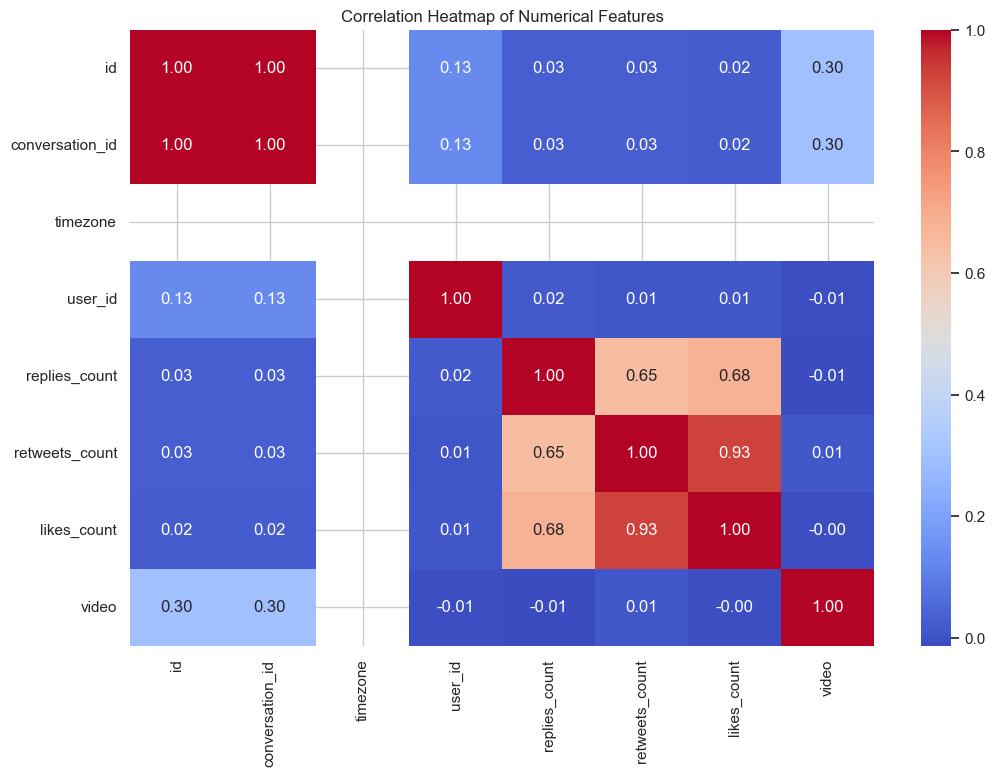

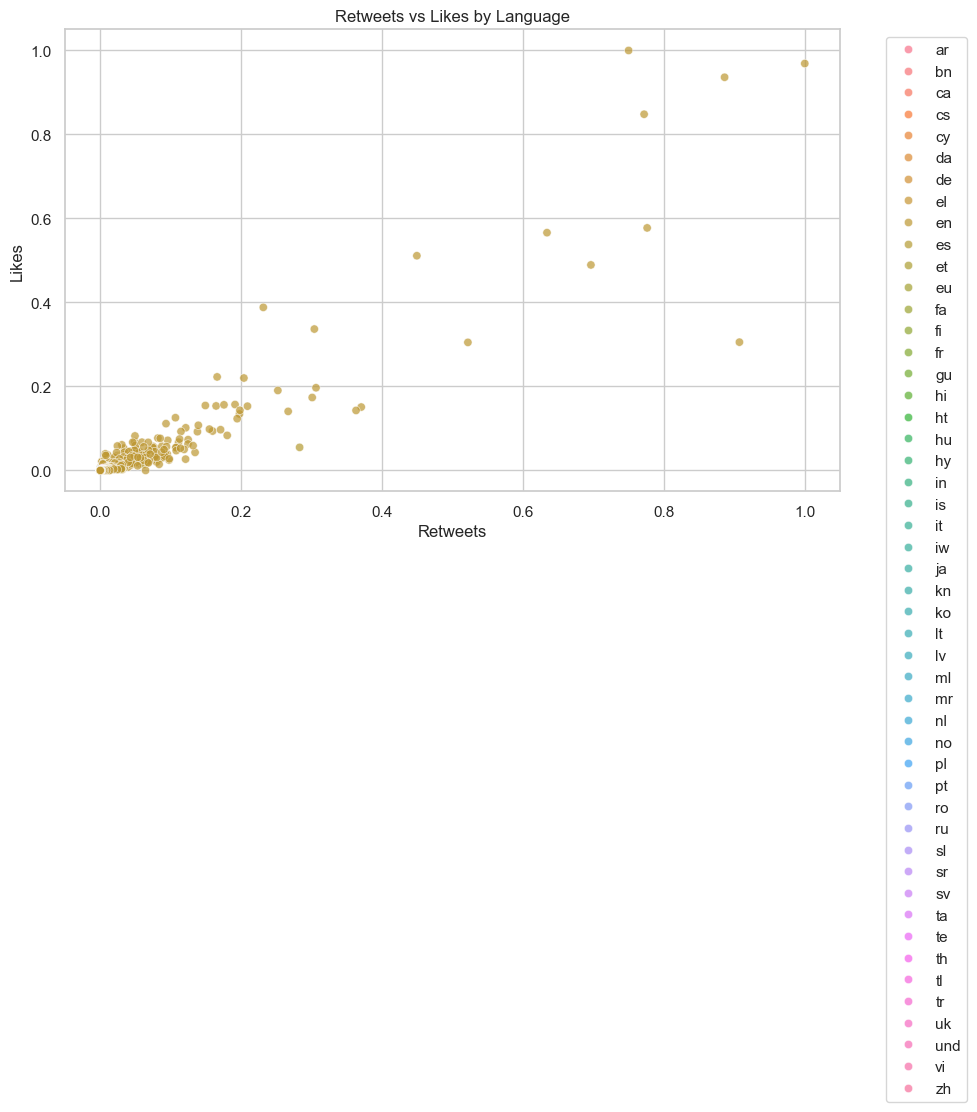

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")


plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(x='retweets_count', y='likes_count', data=df, hue='language', alpha=0.7)
plt.title("Retweets vs Likes by Language")
plt.xlabel("Retweets")
plt.ylabel("Likes")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()


In [30]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from textblob import TextBlob  

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 1  # Positive
    elif polarity < 0:
        return 0  # Negative
    else:
        return None  




def clean_text(text):
    text = re.sub(r"http\S+|www.\S+", "", text)  
    text = re.sub(r"@\w+|#\w+", "", text)        
    text = re.sub(r"[^\w\s]", "", text)          
    text = text.lower()
    return text

df['clean_tweet'] = df['tweet'].apply(clean_text)

df['sentiment'] = df['tweet'].apply(get_sentiment)
df = df.dropna(subset=['sentiment'])  

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_tweet'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.9497246737572603

Confusion Matrix:
 [[ 3237  1083]
 [  250 21944]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.75      0.83      4320
         1.0       0.95      0.99      0.97     22194

    accuracy                           0.95     26514
   macro avg       0.94      0.87      0.90     26514
weighted avg       0.95      0.95      0.95     26514



In [48]:
def predict_sentiment(tweet):
    cleaned = clean_text(tweet)
    vectorized = vectorizer.transform([cleaned])
    
    prediction = model.predict(vectorized)[0]
    prob = model.predict_proba(vectorized)[0]
    
    sentiment = "Positive" if prediction == 1 else "Negative"
    confidence = prob[int(prediction)] * 100

    print(f"\nTweet: \"{tweet}\"")
    print(f"Cleaned: \"{cleaned}\"")
    print(f"Predicted Sentiment: {sentiment} (Confidence: {confidence:.2f}%)")

sample_tweet = "it was a bad "
predict_sentiment(sample_tweet)


Tweet: "it was a bad "
Cleaned: "it was a bad "
Predicted Sentiment: Negative (Confidence: 99.87%)



--- EVALUATION METRICS ---
Accuracy     : 0.9497
Precision    : 0.9530
Recall       : 0.9887
F1 Score     : 0.9705
ROC-AUC Score: 0.9803

Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.75      0.83      4320
         1.0       0.95      0.99      0.97     22194

    accuracy                           0.95     26514
   macro avg       0.94      0.87      0.90     26514
weighted avg       0.95      0.95      0.95     26514



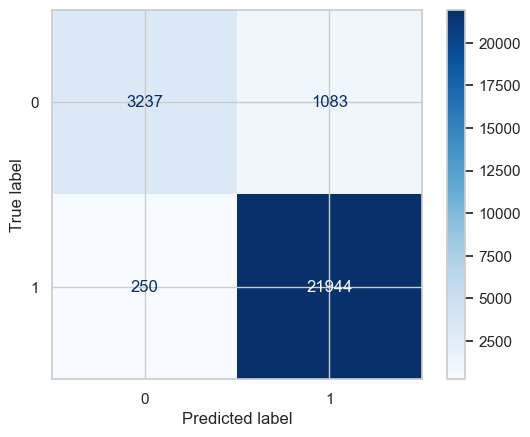

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

acc = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

report = classification_report(y_test, y_pred)

y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

# Display
print("\n--- EVALUATION METRICS ---")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:\n", report)


In [11]:
import pandas as pd
import re
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def clean_text(text):
    text = re.sub(r"http\S+|www.\S+", "", text)  
    text = re.sub(r"@\w+|#\w+", "", text)        
    text = re.sub(r"[^\w\s]", "", text)          
    text = text.lower()
    return text

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
nb_prob = nb_model.predict_proba(X_test)[:, 1]

nb_results = {
    'Model': 'Naive Bayes',
    'Accuracy': accuracy_score(y_test, nb_pred),
    'Precision': precision_score(y_test, nb_pred),
    'Recall': recall_score(y_test, nb_pred),
    'F1 Score': f1_score(y_test, nb_pred),
    'ROC-AUC': roc_auc_score(y_test, nb_prob)
}

print("Naive Bayes Evaluation:")
for k, v in nb_results.items():
    if k != 'Model':
        print(f"{k}: {v:.4f}")




Naive Bayes Evaluation:
Accuracy: 0.8778
Precision: 0.8752
Recall: 0.9960
F1 Score: 0.9317
ROC-AUC: 0.9407


In [50]:
def predict_sentiment(tweet):
    cleaned = clean_text(tweet)
    vectorized = vectorizer.transform([cleaned])
    
    prediction = nb_model.predict(vectorized)[0]
    prob = nb_model.predict_proba(vectorized)[0]
    
    sentiment = "Positive" if prediction == 1 else "Negative"
    confidence = prob[int(prediction)] * 100
    
    print(f"\nTweet: \"{tweet}\"")
    print(f"Cleaned: \"{cleaned}\"")
    print(f"Predicted Sentiment: {sentiment} (Confidence: {confidence:.2f}%)")

sample_tweet = "it was a bad a experience"
predict_sentiment(sample_tweet)


Tweet: "it was a bad a experience"
Cleaned: "it was a bad a experience"
Predicted Sentiment: Negative (Confidence: 51.16%)


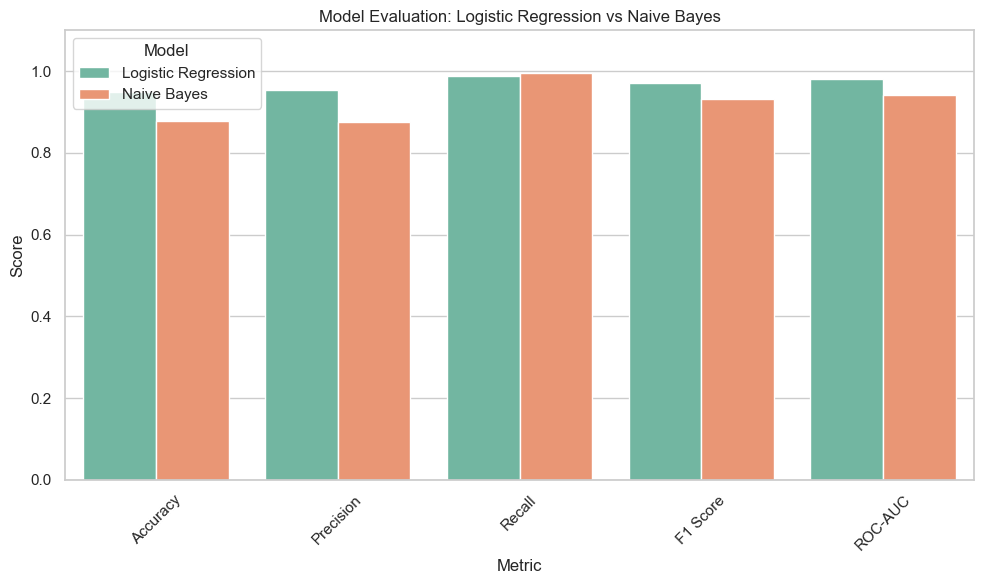

In [13]:
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

log_results = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, log_pred),
    'Precision': precision_score(y_test, log_pred),
    'Recall': recall_score(y_test, log_pred),
    'F1 Score': f1_score(y_test, log_pred),
    'ROC-AUC': roc_auc_score(y_test, log_prob)
}

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_prob = nb_model.predict_proba(X_test)[:, 1]

nb_results = {
    'Model': 'Naive Bayes',
    'Accuracy': accuracy_score(y_test, nb_pred),
    'Precision': precision_score(y_test, nb_pred),
    'Recall': recall_score(y_test, nb_pred),
    'F1 Score': f1_score(y_test, nb_pred),
    'ROC-AUC': roc_auc_score(y_test, nb_prob)
}
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame([log_results, nb_results])

sns.set(style="whitegrid")

results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(x="Metric", y="Score", hue="Model", data=results_melted, palette="Set2")

plt.title("Model Evaluation: Logistic Regression vs Naive Bayes")
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.legend(title="Model")
plt.tight_layout()
plt.show()
